# ------------------------ Dataset Sampling --------------------------- 

In [184]:
import numpy as np
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')


### Creating Dataset

In [185]:
from sklearn.datasets import make_classification   #make_classification for creating data set
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

### Creating Dataframe

In [186]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
df.head()

,col1,col2,col3,col4,col5,target
0,0.654825,1.178191,-0.210889,1.411734,3.558091,0
1,-0.990482,0.654202,0.627402,-0.235102,-2.816608,1
2,-0.307904,0.852561,1.834323,0.881235,-0.417106,0
3,-0.107486,1.587551,0.989032,1.247673,3.150366,0
4,-0.500285,0.827512,0.558191,2.816340,1.020124,0


In [187]:
print(df.shape)

(100, 6)


-----------
# Creating Three Different Decision Tree Classifier Model

In [188]:
from sklearn.tree import DecisionTreeClassifier
DTC1 = DecisionTreeClassifier()
DTC2 = DecisionTreeClassifier()
DTC3 = DecisionTreeClassifier()

---------
# ---------------------- Splitting Of Dataset ---------------------------

## 1. Splitting of dataset with row sampling

#### Function for row Sampling 

In [189]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

### function for combined sampling

-----
## ------------- Creating 3 different Dataset with Row_Sampling -----------------

In [190]:
df1 = sample_rows(df,0.1)
df2 = sample_rows(df,0.1)
df3 = sample_rows(df,0.1)

In [191]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


### Training 3 Different Model on different Dataset

In [192]:
DTC1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
DTC2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
DTC3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

#### Decision Tree of 1st Model

[Text(0.5, 0.75, 'x[0] <= -0.684\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]')]

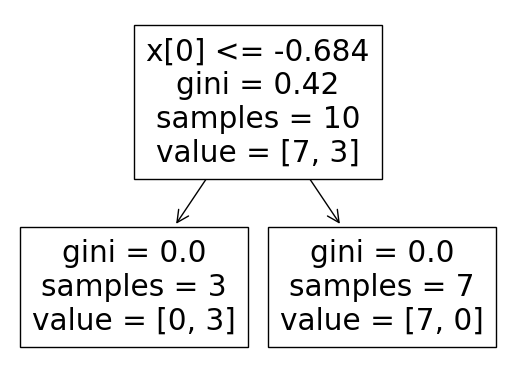

In [193]:
from sklearn.tree import plot_tree
plot_tree(DTC1)

#### Decision Tree of 2nd Model

[Text(0.6, 0.875, 'x[2] <= -0.521\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.4, 0.625, 'x[4] <= 2.462\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.6, 0.375, 'x[4] <= 2.967\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

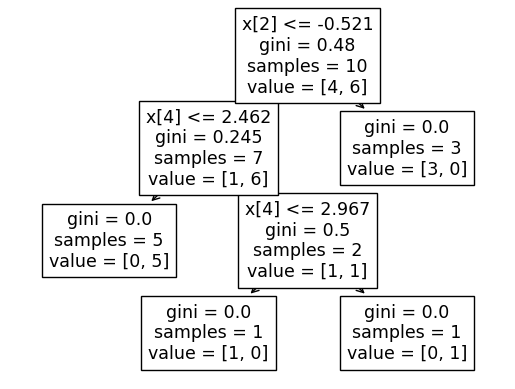

In [194]:
plot_tree(DTC2)

#### Decision Tree of 3rd Model

[Text(0.5, 0.75, 'x[0] <= 0.42\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]')]

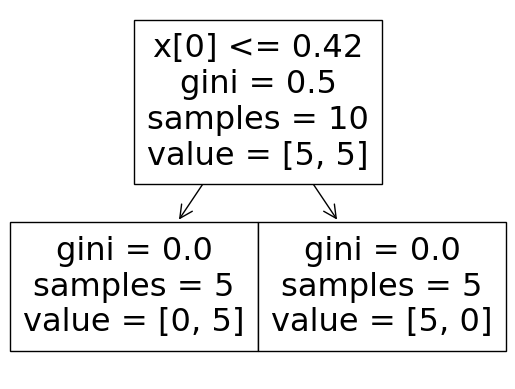

In [195]:
plot_tree(DTC3)

### Testing of Model
on Testing Dataset 
[-0.668131,0.366572,-1.149445,2.231536,-1.428946]

In [196]:
Predict_DTC1=DTC1.predict(np.array([-0.668131,0.366572,-1.149445,2.231536,-1.428946]).reshape(1,5))
Predict_DTC2= DTC2.predict(np.array([-0.668131,0.366572,-1.149445,2.231536,-1.428946]).reshape(1,5))
Predict_DTC3= DTC3.predict(np.array([-0.668131,0.366572,-1.149445,2.231536,-1.428946]).reshape(1,5))

In [197]:
print("Predictation of Model 1:- ",Predict_DTC1)
print("Predictation of Model 2:- ",Predict_DTC2)
print("Predictation of Model 3:-",Predict_DTC3)
### Majority count will be the output of the Model

Predictation of Model 1:-  [0]
Predictation of Model 2:-  [1]
Predictation of Model 3:- [1]


-------
# Sampling of Dataset with Feature Selection

#### function for feature sampling

In [198]:
import random
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

### Creating 3 different Dataset with Feature Selection

In [199]:
df1 = sample_features(df,0.8)
df2 = sample_features(df,0.8)
df3 = sample_features(df,0.8)
df1

,col2,col1,col5,col3,target
0,1.178191,0.654825,3.558091,-0.210889,0
1,0.654202,-0.990482,-2.816608,0.627402,1
2,0.852561,-0.307904,-0.417106,1.834323,0
3,1.587551,-0.107486,3.150366,0.989032,0
4,0.827512,-0.500285,1.020124,0.558191,0
...,...,...,...,...,...
95,0.616542,0.066050,3.078024,-0.825483,0
96,1.095584,1.892321,1.286893,0.946465,0
97,0.997844,0.681350,-0.690210,0.115716,1
98,0.222517,0.567966,1.131965,-0.917601,0


### Training 3 Different Model on different Dataset

In [200]:
DTC1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
DTC2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
DTC3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

### Decision Tree of 1st Model

[Text(0.4722222222222222, 0.9375, 'x[1] <= -0.115\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.2222222222222222, 0.8125, 'x[2] <= 0.452\ngini = 0.227\nsamples = 46\nvalue = [6, 40]'),
 Text(0.1111111111111111, 0.6875, 'x[3] <= 1.681\ngini = 0.054\nsamples = 36\nvalue = [1, 35]'),
 Text(0.05555555555555555, 0.5625, 'gini = 0.0\nsamples = 34\nvalue = [0, 34]'),
 Text(0.16666666666666666, 0.5625, 'x[1] <= -0.398\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3333333333333333, 0.6875, 'x[3] <= -1.88\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2777777777777778, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3888888888888889, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7222222222222222, 0.8125, 'x[0] <= 0.428\ngini = 0.324\nsamples = 54\nvalue = [43, 11]'),
 Text(0.5555555555555556, 0.

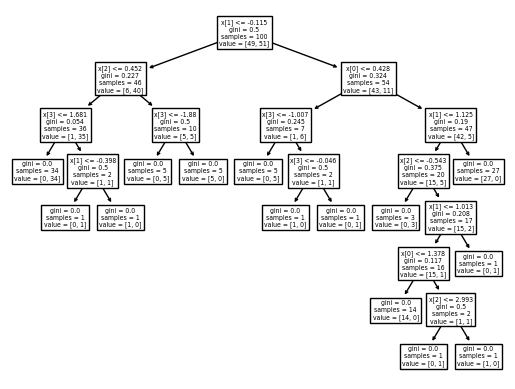

In [201]:
from sklearn.tree import plot_tree
plot_tree(DTC1)

### Decision Tree of 2nd Model

[Text(0.5, 0.9375, 'x[3] <= -0.115\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.8125, 'x[0] <= 0.452\ngini = 0.227\nsamples = 46\nvalue = [6, 40]'),
 Text(0.125, 0.6875, 'x[3] <= -0.398\ngini = 0.054\nsamples = 36\nvalue = [1, 35]'),
 Text(0.0625, 0.5625, 'gini = 0.0\nsamples = 33\nvalue = [0, 33]'),
 Text(0.1875, 0.5625, 'x[2] <= 0.628\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.125, 0.4375, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.25, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.6875, 'x[2] <= 0.383\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.3125, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4375, 0.5625, 'x[2] <= 1.531\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.375, 0.4375, 'x[3] <= -0.449\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.3125, 0.3125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4375, 0.3125, 'x[2] <= 1.098\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3

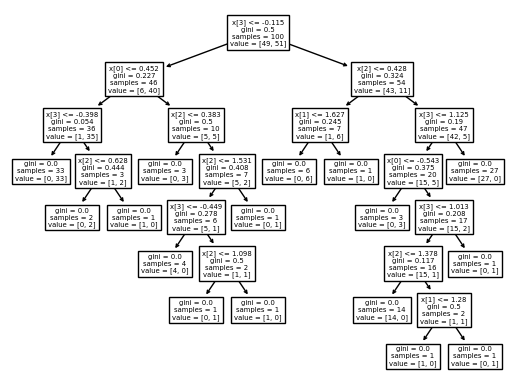

In [202]:
from sklearn.tree import plot_tree
plot_tree(DTC2)

### Decision Tree of 3rd Model

[Text(0.425, 0.9375, 'x[0] <= -0.115\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.2, 0.8125, 'x[2] <= 0.452\ngini = 0.227\nsamples = 46\nvalue = [6, 40]'),
 Text(0.1, 0.6875, 'x[3] <= 1.681\ngini = 0.054\nsamples = 36\nvalue = [1, 35]'),
 Text(0.05, 0.5625, 'gini = 0.0\nsamples = 34\nvalue = [0, 34]'),
 Text(0.15, 0.5625, 'x[2] <= -1.843\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.6875, 'x[3] <= -1.88\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.35, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.65, 0.8125, 'x[1] <= 0.428\ngini = 0.324\nsamples = 54\nvalue = [43, 11]'),
 Text(0.5, 0.6875, 'x[3] <= -1.007\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.45, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.55, 0.5625, 'x[3] <= -0.046\ngini =

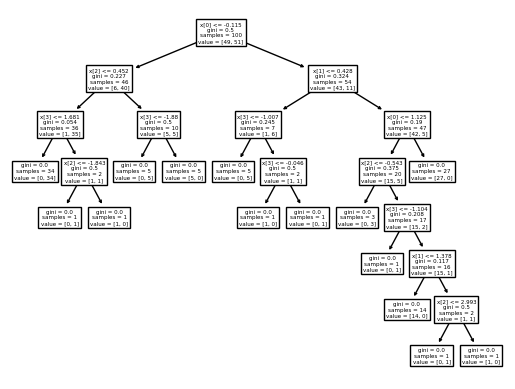

In [203]:
from sklearn.tree import plot_tree
plot_tree(DTC3)

### Testing of Model
on Testing Dataset 
[-0.930649,-0.354331,-0.219922,1.388074]
Output :- 0

In [204]:
Predict_DTC1=DTC1.predict(np.array([-0.930649,-0.354331,-0.219922,1.388074]).reshape(1,4))
Predict_DTC2= DTC2.predict(np.array([-0.930649,-0.354331,-0.219922,1.388074]).reshape(1,4))
Predict_DTC3= DTC3.predict(np.array([-0.930649,-0.354331,-0.219922,1.388074]).reshape(1,4))

In [205]:
print("Predictation of Model 1:- ",Predict_DTC1)
print("Predictation of Model 2:- ",Predict_DTC2)
print("Predictation of Model 3:-",Predict_DTC3)
### Majority count will be the output of the Model

Predictation of Model 1:-  [1]
Predictation of Model 2:-  [1]
Predictation of Model 3:- [1]


-------
# Sampling of Dataset with Combined_Sampling

In [206]:
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

### Creating 3 different Dataset with Feature Selection

In [207]:
df1 = combined_sampling(df,0.5,0.5)
df2 = combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)
df1

,col5,col3,target
81,2.369103,-0.358681,0
4,1.020124,0.558191,0
60,-1.113275,0.533567,1
93,-0.038004,2.115040,0
3,3.150366,0.989032,0
26,-0.814774,-0.796561,1
28,-0.351164,1.834962,0
18,1.787290,-3.387439,1
94,3.274799,-1.483853,0
57,-1.574228,0.587786,1


### Training 3 Different Model on different Dataset

In [208]:
DTC1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
DTC2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
DTC3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

### Decision Tree of 1st Model

[Text(0.4444444444444444, 0.9, 'x[0] <= -0.546\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2222222222222222, 0.7, 'x[1] <= 1.509\ngini = 0.188\nsamples = 19\nvalue = [2, 17]'),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.7, 'x[1] <= -2.328\ngini = 0.383\nsamples = 31\nvalue = [23, 8]'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7777777777777778, 0.5, 'x[1] <= -0.894\ngini = 0.147\nsamples = 25\nvalue = [23, 2]'),
 Text(0.6666666666666666, 0.3, 'x[0] <= 1.69\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.5555555555555556, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.7777777777777778, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8888888888888888, 0.3, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]')]

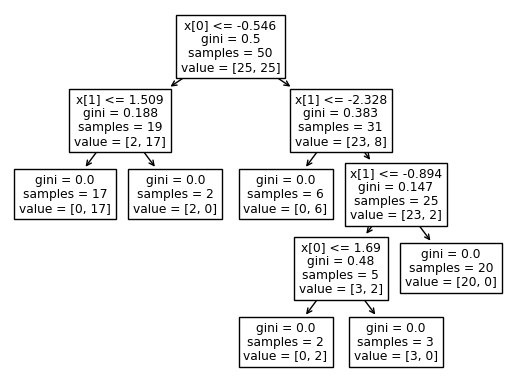

In [209]:
from sklearn.tree import plot_tree
plot_tree(DTC1)

### Decision Tree of 2nd Model

[Text(0.39285714285714285, 0.9, 'x[1] <= -0.551\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.14285714285714285, 0.7, 'x[0] <= 1.025\ngini = 0.278\nsamples = 24\nvalue = [4, 20]'),
 Text(0.07142857142857142, 0.5, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.21428571428571427, 0.5, 'x[1] <= -2.599\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.14285714285714285, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2857142857142857, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6428571428571429, 0.7, 'x[0] <= -0.074\ngini = 0.311\nsamples = 26\nvalue = [21, 5]'),
 Text(0.5, 0.5, 'x[1] <= 0.947\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7857142857142857, 0.5, 'x[1] <= 1.069\ngini = 0.117\nsamples = 16\nvalue = [15, 1]'),
 Text(0.7142857142857143, 0.3, 'gini = 0.0\nsamples = 12\nvalue = [12,

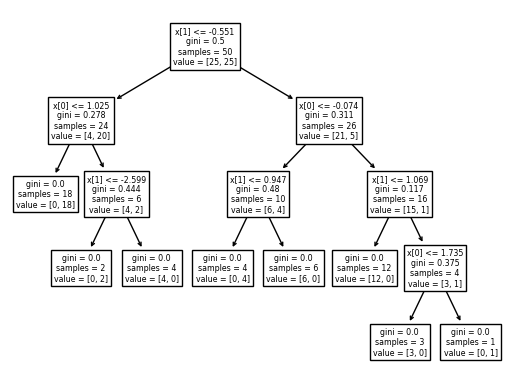

In [210]:
from sklearn.tree import plot_tree
plot_tree(DTC2)

### Decision Tree of 3rd Model

[Text(0.3333333333333333, 0.9, 'x[1] <= -0.751\ngini = 0.487\nsamples = 50\nvalue = [29, 21]'),
 Text(0.2222222222222222, 0.7, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.4444444444444444, 0.7, 'x[0] <= -0.946\ngini = 0.284\nsamples = 35\nvalue = [29, 6]'),
 Text(0.2222222222222222, 0.5, 'x[1] <= 1.852\ngini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.5, 'x[0] <= 2.656\ngini = 0.071\nsamples = 27\nvalue = [26, 1]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.0\nsamples = 25\nvalue = [25, 0]'),
 Text(0.7777777777777778, 0.3, 'x[0] <= 3.004\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8888888888888888, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

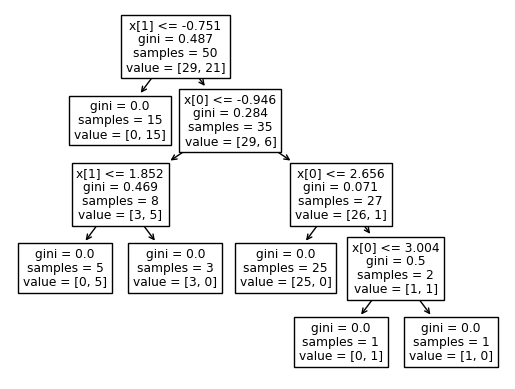

In [211]:
from sklearn.tree import plot_tree
plot_tree(DTC3)

### Testing of Model
on Testing Dataset 
[-0.629725,-2.744925]<br>
Output :- 1

In [212]:
Predict_DTC1=DTC1.predict(np.array([-0.629725,-2.744925]).reshape(1,2))
Predict_DTC2= DTC2.predict(np.array([-0.629725,-2.744925]).reshape(1,2))
Predict_DTC3= DTC3.predict(np.array([-0.629725,-2.744925]).reshape(1,2))

In [213]:
print("Predictation of Model 1:- ",Predict_DTC1)
print("Predictation of Model 2:- ",Predict_DTC2)
print("Predictation of Model 3:-",Predict_DTC3)
### Majority count will be the output of the Model

Predictation of Model 1:-  [1]
Predictation of Model 2:-  [1]
Predictation of Model 3:- [1]
